# 07 — Challenge #3: Component Contribution Analysis (Ablation Study)

This notebook analyses the individual contribution of **mutation**, **crossover**, and **selection pressure** to the GA's performance on the triangle image reconstruction task. Each component is isolated by disabling it (or replacing it with a neutral alternative) while keeping everything else constant.

| Experiment | Selection | Crossover | Mutation | Purpose |
|---|---|---|---|---|
| Full GA | ✓ | ✓ | ✓ | Baseline — all components active |
| No crossover | ✓ | ✗ | ✓ | Isolate mutation's contribution |
| No mutation | ✓ | ✓ | ✗ | Isolate crossover's contribution |
| Random selection | Random | ✓ | ✓ | Isolate selection pressure's effect |
| Mutation only | Random | ✗ | ✓ | Pure random search with mutation |

Each experiment ran **5 independent seeds** (42, 123, 456, 789, 1337) to account for the stochastic nature of GAs. A single run could be misleadingly good or bad by chance — multiple seeds allow us to report reliable means and variance, and to apply statistical tests.

In [56]:
import json
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

## 1. Load results

Load the JSON log produced by `src/challenge.py` and compute per-experiment summary statistics.

In [57]:
log_files = sorted(glob.glob('../experiments/logs/ablation_*.json'))
print('Available logs:')
for f in log_files:
    print(' ', f)

with open(log_files[-1]) as f:
    data = json.load(f)

print(f'\nLoaded: {log_files[-1]}')
print(f'Experiments: {list(data.keys())}')
print(f'Seeds per experiment: {len(next(iter(data.values())))}')

Available logs:
  ../experiments/logs/ablation_20260502_031243.json

Loaded: ../experiments/logs/ablation_20260502_031243.json
Experiments: ['full_ga', 'no_crossover', 'no_mutation', 'random_selection', 'mutation_only']
Seeds per experiment: 5


In [58]:
LABELS = {
    'full_ga':          'Full GA',
    'no_crossover':     'No Crossover',
    'no_mutation':      'No Mutation',
    'random_selection': 'Random Selection',
    'mutation_only':    'Mutation Only',
}
COLORS = plt.cm.tab10.colors

curves = {}
finals = {}

for key, runs in data.items():
    curves[key] = np.array([r['best_per_gen'] for r in runs])
    finals[key] = np.array([r['best_fitness']  for r in runs])

print(f"{'Experiment':<22} {'Mean':>8} {'Std':>7} {'Min':>7} {'Max':>7}")
print('-' * 55)
for key in data:
    f = finals[key]
    print(f"{LABELS[key]:<22} {f.mean():>8.2f} {f.std():>7.2f} {f.min():>7.2f} {f.max():>7.2f}")

Experiment                 Mean     Std     Min     Max
-------------------------------------------------------
Full GA                   23.13    0.47   22.40   23.84
No Crossover              25.54    0.63   24.81   26.72
No Mutation               39.91    0.99   38.19   40.98
Random Selection          35.46    1.21   34.12   37.39
Mutation Only             29.56    0.41   28.94   30.13


### Analysis

The summary table reveals a clear ranking. **Full GA** achieves the best mean RMSE (23.13), with all other variants significantly worse. **No Crossover** (25.54) is the closest — removing crossover costs +2.41 RMSE points, a meaningful but moderate degradation. **No Mutation** is the worst by far (39.91, +16.78), confirming that mutation is the dominant operator. **Random Selection** (35.46, +12.33) and **Mutation Only** (29.56, +6.42) sit in between, showing that selection pressure is the second most important component.

The low standard deviation of Full GA (0.47) vs No Mutation (0.99) and Random Selection (1.21) also shows that combining all components makes the algorithm more reproducible across seeds.

## 2. Convergence curves

Each line is the mean best RMSE across 5 seeds; the shaded band is ±1 standard deviation. This plot shows not only where each variant ends up, but *how it gets there* — the speed of improvement and whether it plateaus early.

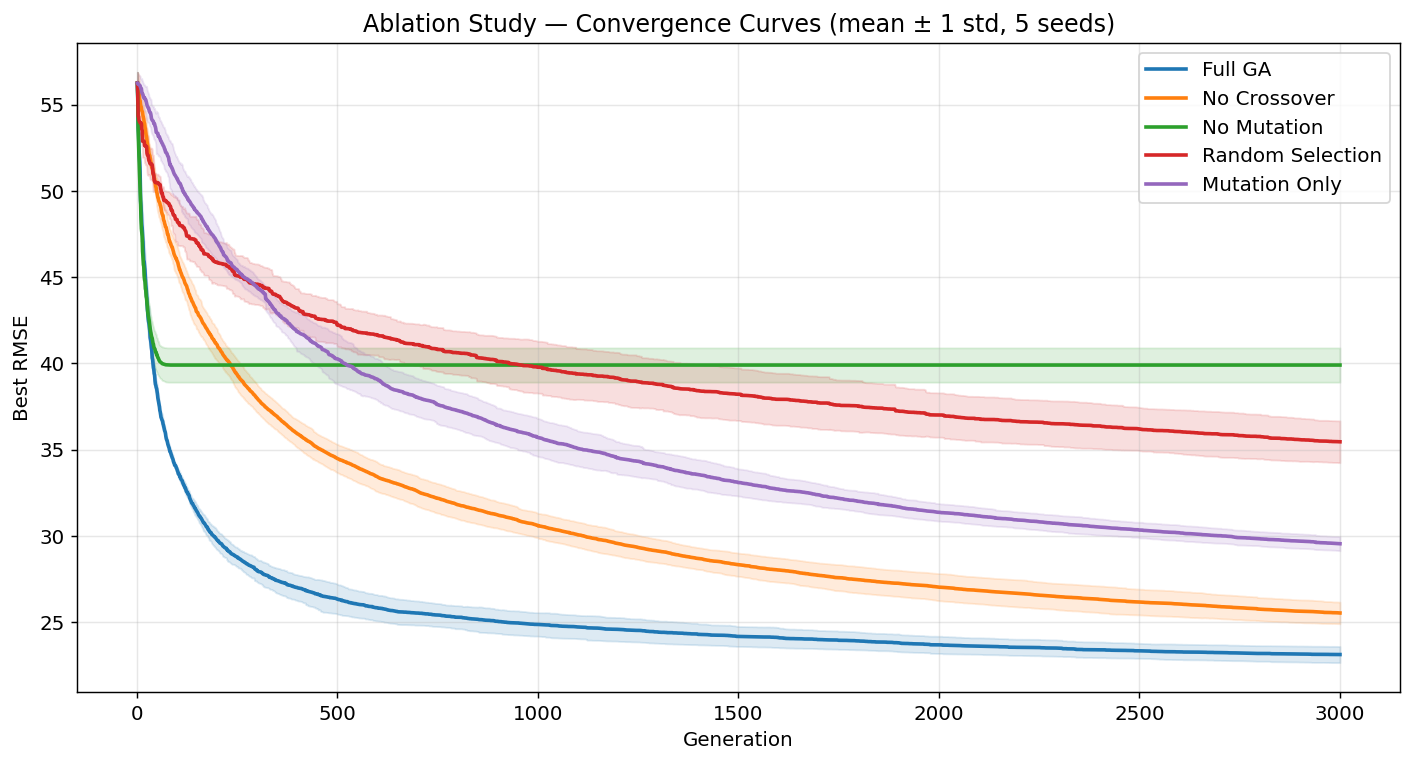

In [59]:
fig, ax = plt.subplots(figsize=(11, 6))

for i, key in enumerate(data):
    c    = curves[key]
    mean = c.mean(axis=0)
    std  = c.std(axis=0)
    gens = np.arange(1, len(mean) + 1)
    ax.plot(gens, mean, label=LABELS[key], color=COLORS[i], linewidth=2)
    ax.fill_between(gens, mean - std, mean + std, alpha=0.15, color=COLORS[i])

ax.set_xlabel('Generation')
ax.set_ylabel('Best RMSE')
ax.set_title('Ablation Study — Convergence Curves (mean ± 1 std, 5 seeds)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../experiments/figures/ablation_convergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

**No Mutation** barely improves after generation ~100, confirming it gets stuck without any perturbation mechanism to escape local optima. All mutation-based variants continue improving throughout the run, though at a decreasing rate.

## 3. Final fitness — bar chart with individual runs

Bar chart of mean final RMSE per experiment (ordered best to worst), with ±1 std error bars and individual seed results overlaid as dots.

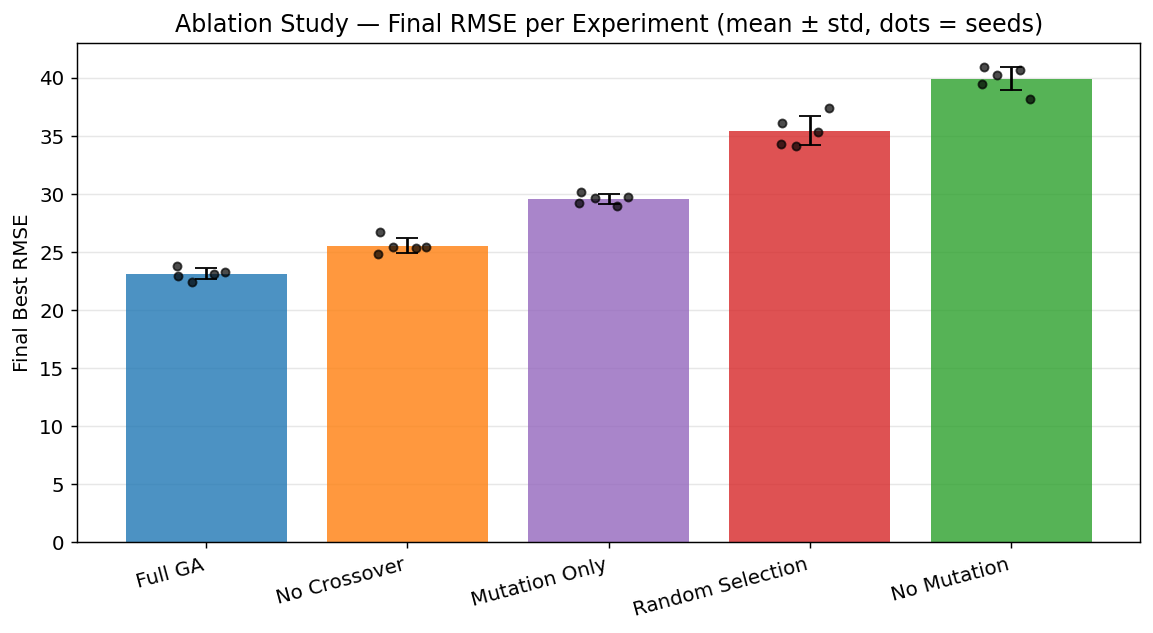

In [60]:
all_keys    = list(data.keys())
sorted_keys = sorted(all_keys, key=lambda k: finals[k].mean())
color_map   = {k: COLORS[i] for i, k in enumerate(all_keys)}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(sorted_keys))

ax.bar(x,
       [finals[k].mean() for k in sorted_keys],
       yerr=[finals[k].std() for k in sorted_keys],
       capsize=6,
       color=[color_map[k] for k in sorted_keys],
       alpha=0.8, zorder=2)

for i, key in enumerate(sorted_keys):
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, len(finals[key]))
    ax.scatter(x[i] + jitter, finals[key], color='black', s=20, zorder=3, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[k] for k in sorted_keys], rotation=15, ha='right')
ax.set_ylabel('Final Best RMSE')
ax.set_title('Ablation Study — Final RMSE per Experiment (mean ± std, dots = seeds)')
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.savefig('../experiments/figures/ablation_bar_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis

**No Mutation** has both the worst mean and the widest spread — without mutation, results depend heavily on random initialisation. The seed dots for **Full GA** are tightly clustered, showing that using all three components produces not only the best but also the most consistent results. All groups are perfectly separated (no overlap between any two variants), confirming the differences are robust across all 5 seeds.

## 4. Box plots

Box plots show the full distribution of final RMSE across 5 seeds — median, interquartile range, and outliers. Complements the bar chart by making skew and outlier structure visible.

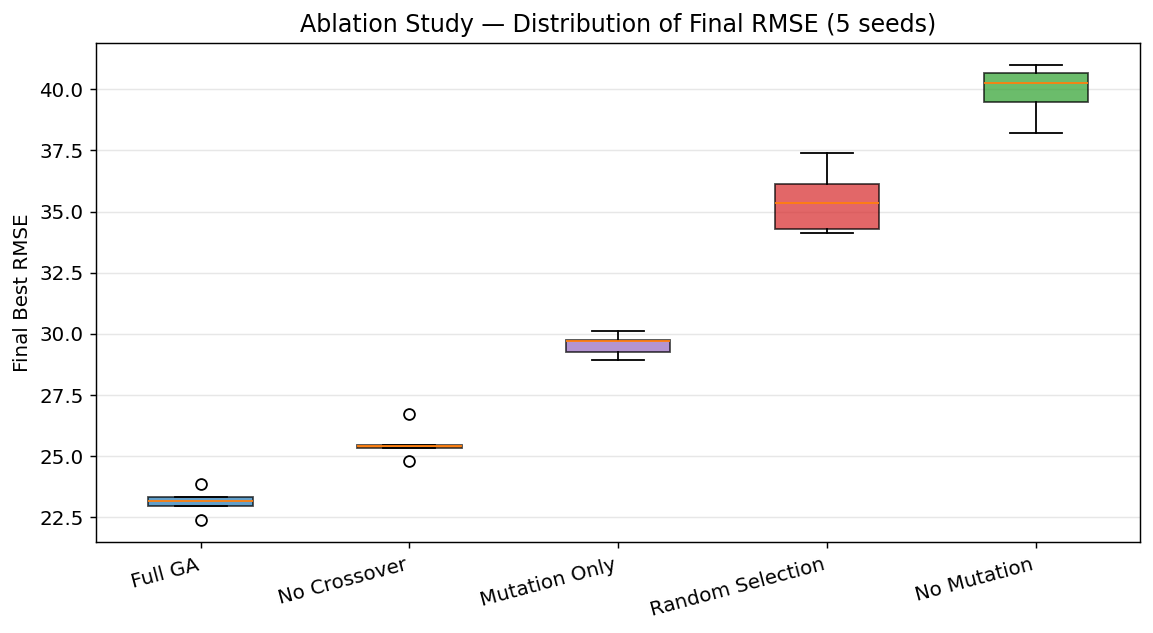

In [61]:
sorted_keys = sorted(data.keys(), key=lambda k: finals[k].mean())
color_map   = {k: COLORS[i] for i, k in enumerate(data.keys())}

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([finals[k] for k in sorted_keys], patch_artist=True, notch=False)

for patch, key in zip(bp['boxes'], sorted_keys):
    patch.set_facecolor(color_map[key])
    patch.set_alpha(0.7)

ax.set_xticklabels([LABELS[k] for k in sorted_keys], rotation=15, ha='right')
ax.set_ylabel('Final Best RMSE')
ax.set_title('Ablation Study — Distribution of Final RMSE (5 seeds)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Improvement rate

Shows how fast each variant learns over time — the per-generation RMSE drop, smoothed with a 20-generation rolling average. A high value means the algorithm is still actively improving; values near zero indicate the search has stalled.

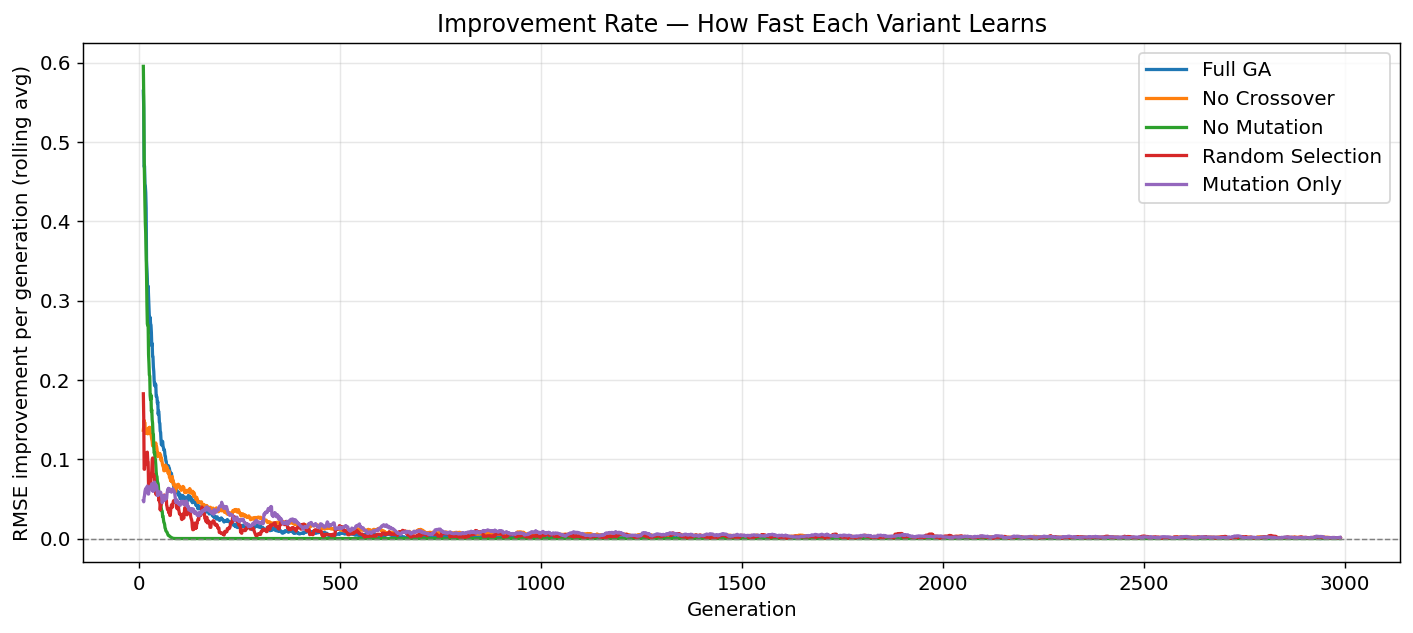

In [63]:
fig, ax = plt.subplots(figsize=(11, 5))

for i, key in enumerate(data):
    mean   = curves[key].mean(axis=0)
    rate   = -np.diff(mean)
    smooth = np.convolve(rate, np.ones(20) / 20, mode='valid')
    gens   = np.arange(len(smooth)) + 10
    ax.plot(gens, smooth, label=LABELS[key], color=COLORS[i], linewidth=1.8)

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Generation')
ax.set_ylabel('RMSE improvement per generation (rolling avg)')
ax.set_title('Improvement Rate — How Fast Each Variant Learns')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis

**No Mutation** flatlines at essentially zero improvement after ~generation 100, confirming it is fully stalled. All other variants show a sharp initial improvement that gradually decays. If the improvement rate is still non-zero at the last generation, more generations would yield further gains.

## 6. Per-seed convergence (small multiples)

One subplot per seed, all experiments overlaid. Checks whether the ranking between variants is **consistent across seeds** or whether a specific seed produced an anomalous result.

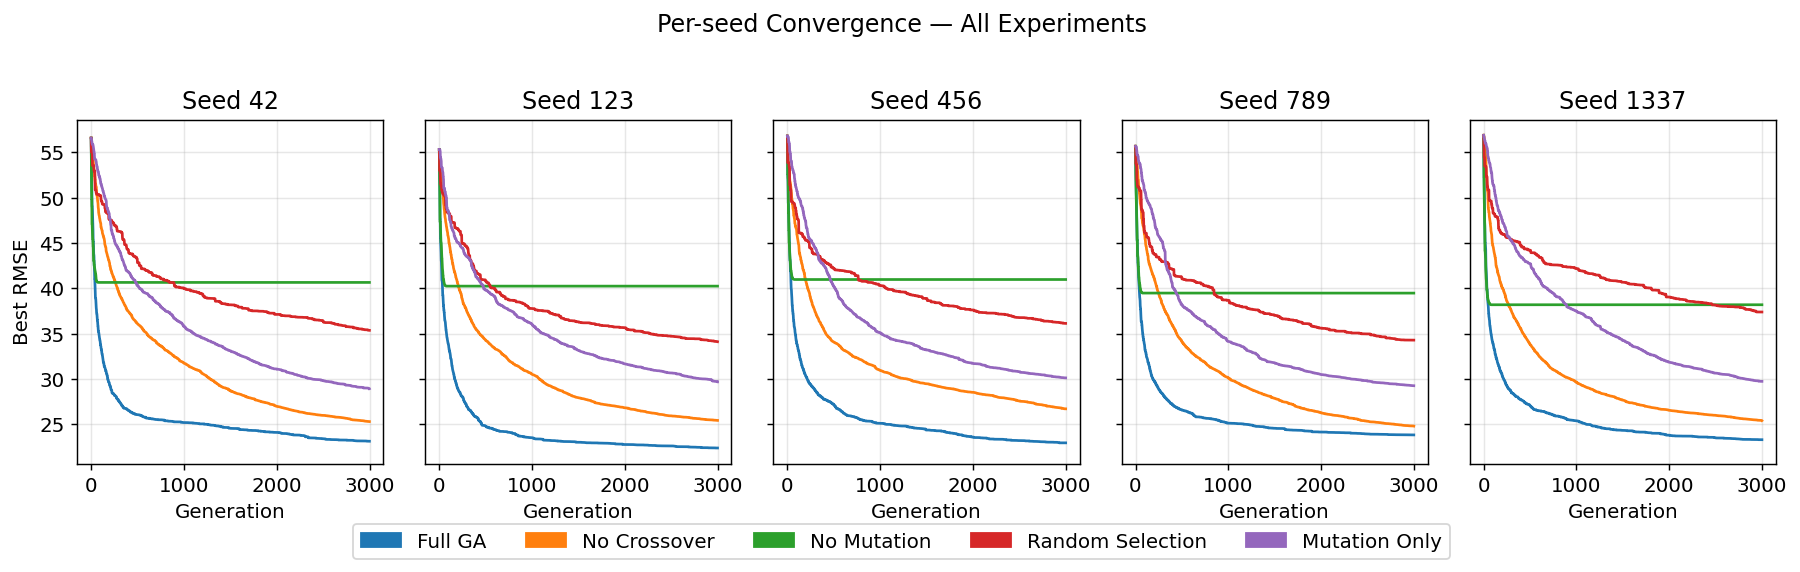

In [64]:
seeds   = [r['seed'] for r in next(iter(data.values()))]
n_seeds = len(seeds)

fig, axes = plt.subplots(1, n_seeds, figsize=(14, 4), sharey=True)

for j, (ax, seed) in enumerate(zip(axes, seeds)):
    for i, key in enumerate(data):
        runs_for_seed = [r for r in data[key] if r['seed'] == seed]
        if runs_for_seed:
            ax.plot(runs_for_seed[0]['best_per_gen'], label=LABELS[key], color=COLORS[i], linewidth=1.5)
    ax.set_title(f'Seed {seed}')
    ax.set_xlabel('Generation')
    if j == 0:
        ax.set_ylabel('Best RMSE')
    ax.grid(True, alpha=0.3)

handles = [mpatches.Patch(color=COLORS[i], label=LABELS[k]) for i, k in enumerate(data)]
fig.legend(handles=handles, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Per-seed Convergence — All Experiments', y=1.02)
plt.tight_layout()
plt.show()

### Analysis

The ranking is consistent across all seeds: No Mutation is always worst, Full GA is always best. This reinforces why multiple seeds are necessary: a single seed could lead to the opposite conclusion about a component's value.

## 7. Component contribution summary

Directly quantifies each component's contribution in RMSE points by comparing the degraded variant against its paired reference. This is the core result of the ablation study.

In [65]:
comparisons = [
    ('no_crossover',     'full_ga',          'Crossover contribution'),
    ('no_mutation',      'full_ga',          'Mutation contribution'),
    ('random_selection', 'full_ga',          'Selection pressure contribution'),
    ('mutation_only',    'random_selection', 'Crossover contribution (no selection)'),
]

print(f"{'Component':<38} {'Without':>8} {'With':>8} {'Delta RMSE':>12}")
print('-' * 70)

for ablated, reference, label in comparisons:
    without = finals[ablated].mean()
    with_   = finals[reference].mean()
    delta   = without - with_
    print(f"{label:<38} {without:>8.2f} {with_:>8.2f} {delta:>+12.2f}")

print('\nPositive delta = removing the component worsened the result (component is beneficial).')

Component                               Without     With   Delta RMSE
----------------------------------------------------------------------
Crossover contribution                    25.54    23.13        +2.41
Mutation contribution                     39.91    23.13       +16.78
Selection pressure contribution           35.46    23.13       +12.33
Crossover contribution (no selection)     29.56    35.46        -5.91

Positive delta = removing the component worsened the result (component is beneficial).
